--- k-Nearest Neighbors Classification ---
Training dataset: First 50 points labeled based on the rule (x <= 0.5 -> Class1, x > 0.5 -> Class2)
Testing dataset: Remaining 50 points to be classified

Results for k = 1:
Point x1 (value: 0.4983) is classified as Class1
Point x2 (value: 0.7446) is classified as Class2
Point x3 (value: 0.0020) is classified as Class1
Point x4 (value: 0.6323) is classified as Class2
Point x5 (value: 0.1828) is classified as Class1
Point x6 (value: 0.1506) is classified as Class1
Point x7 (value: 0.6068) is classified as Class2
Point x8 (value: 0.1986) is classified as Class1
Point x9 (value: 0.5950) is classified as Class2
Point x10 (value: 0.8158) is classified as Class2
Point x11 (value: 0.3654) is classified as Class1
Point x12 (value: 0.2469) is classified as Class1
Point x13 (value: 0.7963) is classified as Class2
Point x14 (value: 0.1553) is classified as Class1
Point x15 (value: 0.3865) is classified as Class1
Point x16 (value: 0.8647) is classified as

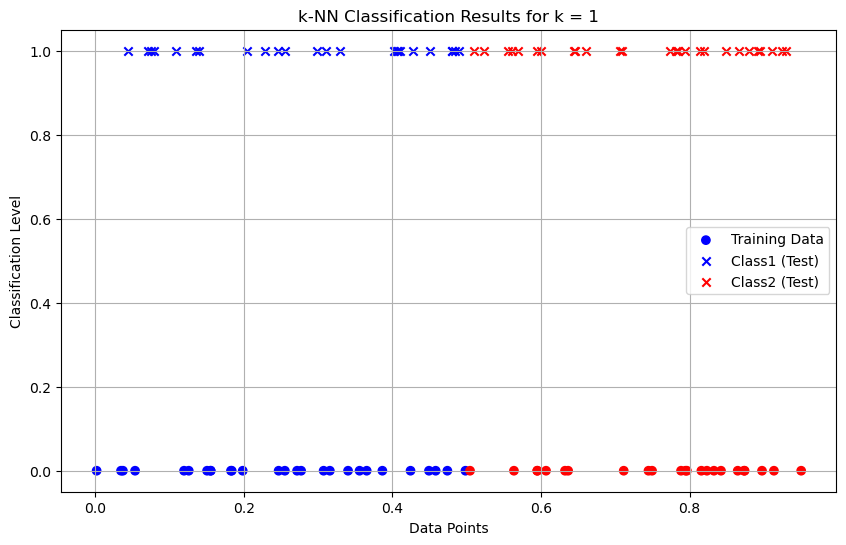

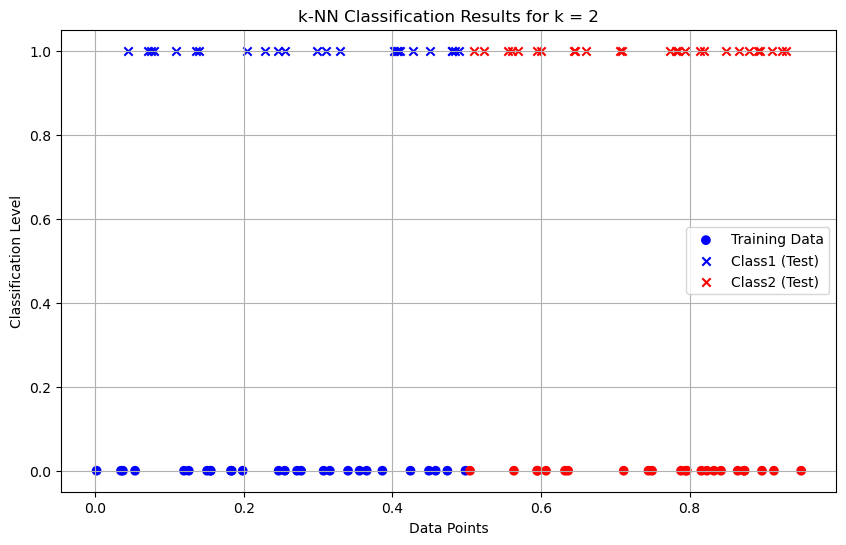

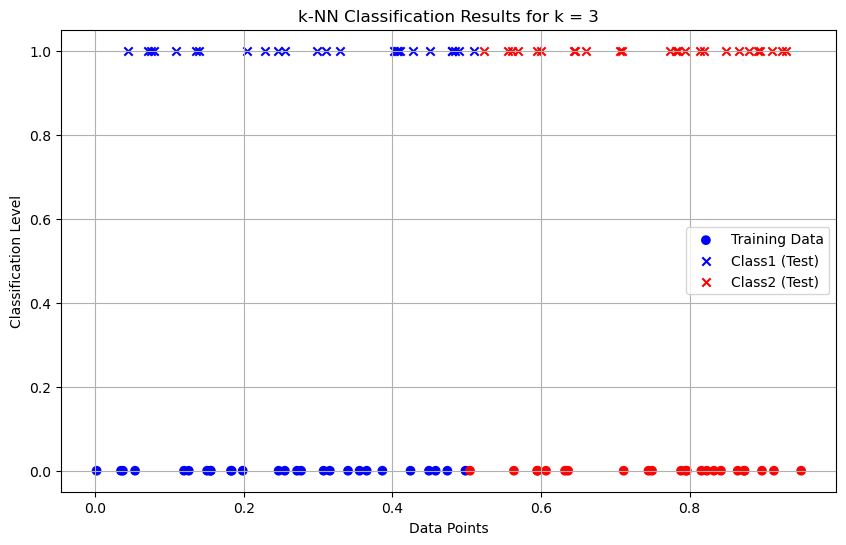

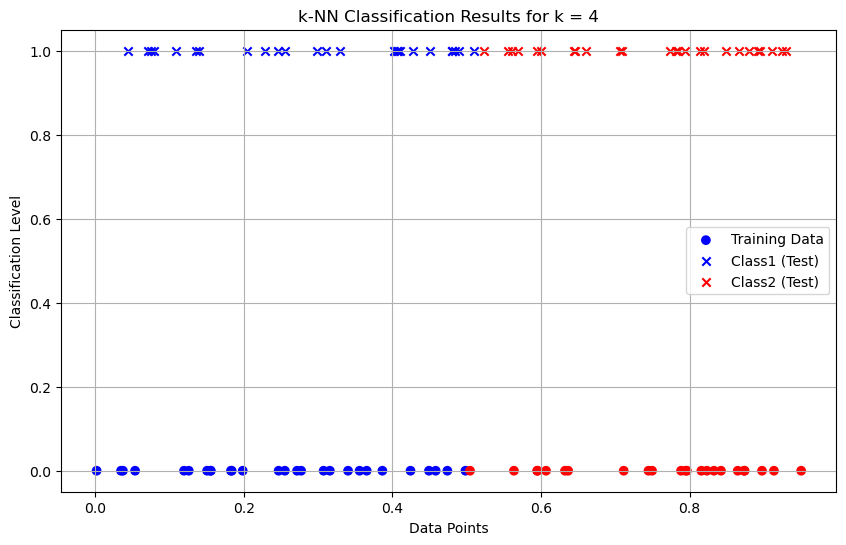

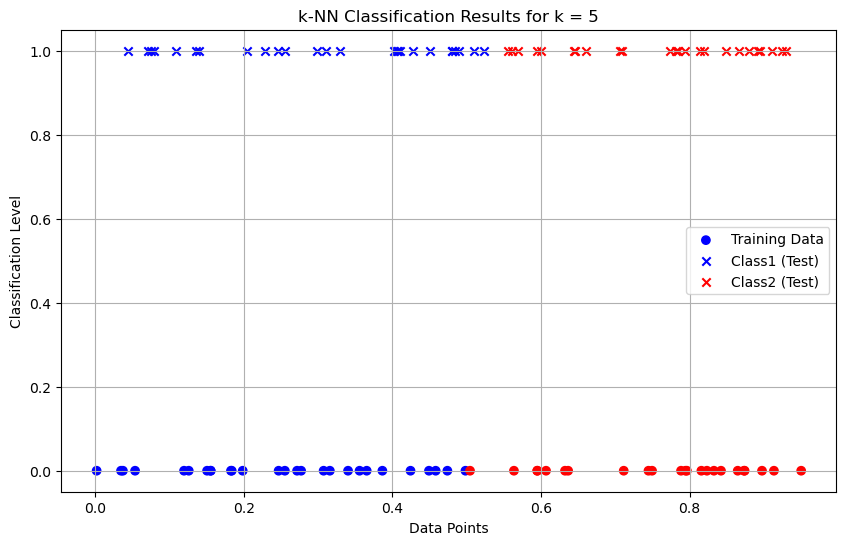

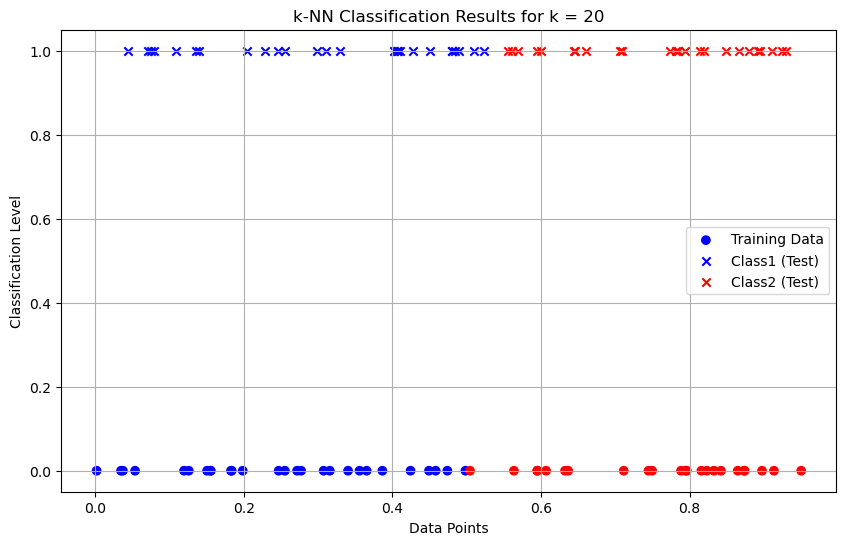

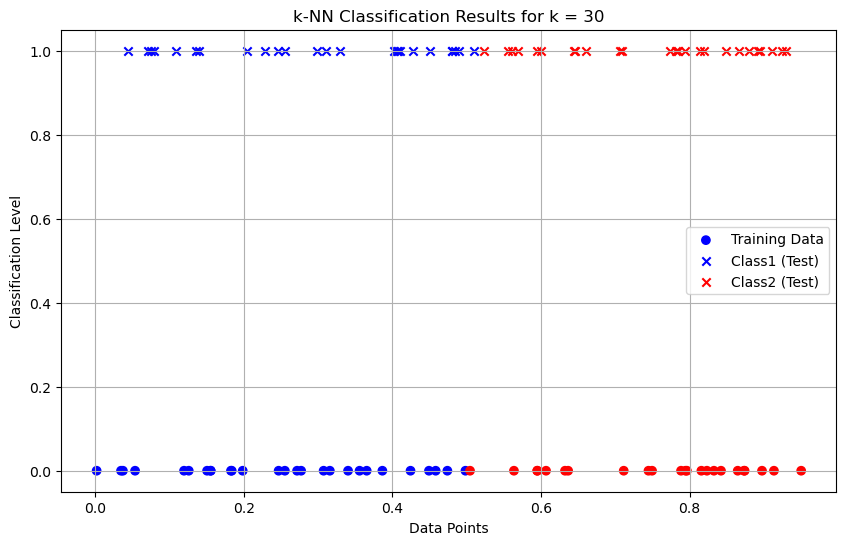

In [6]:
import numpy as np
import matplotlib.pyplot as plt 
from collections import Counter 
# Generate random data 
data = np.random.rand(100) 
labels = ["Class1" if x <= 0.5 else "Class2" for x in data[:50]] 
# Function to compute Euclidean distance 
def euclidean_distance(x1, x2): 
    return abs(x1 - x2) 
# k-NN classifier function 
def knn_classifier(train_data, train_labels, test_point, k): 
    distances = [(euclidean_distance(test_point, train_data[i]), train_labels[i]) for i in range(len(train_data))] 
    distances.sort(key=lambda x: x[0])  # Sort by distance 
    k_nearest_neighbors = distances[:k]  # Get k nearest neighbors 
    k_nearest_labels = [label for _, label in k_nearest_neighbors]  # Extract the labels 
    return Counter(k_nearest_labels).most_common(1)[0][0]
# Prepare the training and test data 
train_data = data[:50]  # First 50 points for training 
train_labels = labels  # Corresponding labels for training 
test_data = data[50:]  # Remaining 50 points for testing 
# Values of k to test 
k_values = [1, 2, 3, 4, 5, 20, 30] 
print("--- k-Nearest Neighbors Classification ---") 
print("Training dataset: First 50 points labeled based on the rule (x <= 0.5 -> Class1, x > 0.5 -> Class2)") 
print("Testing dataset: Remaining 50 points to be classified\n") 
# Store the results for each k value 
results = {} 
# Loop over different values of k 
for k in k_values: 
    print(f"Results for k = {k}:") 
    classified_labels = [knn_classifier(train_data, train_labels, test_point, k) for test_point in test_data] 
    results[k] = classified_labels
    #print(classified_labels)
    for i, label in enumerate(train_labels, start=1):
        print(f"Point x{i} (value: {train_data[i - 1]:.4f}) is classified as {label}")
    print("\n")
# Output the classification results 
for k in k_values:
    print(f"\nDetailed Results for k = {k}:")
    classified_labels = results[k]
    for i, label in enumerate(classified_labels, start=51):
        print(f"Point x{i} (value: {test_data[i - 51]:.4f}) is classified as {label}") 
print("\n")
print("Classification complete.\n") 
# Visualize the classification results for each k value 
for k in k_values: 
    classified_labels = results[k] 
    class1_points = [test_data[i] for i in range(len(test_data)) if classified_labels[i] == "Class1"] 
    class2_points = [test_data[i] for i in range(len(test_data)) if classified_labels[i] == "Class2"] 
    plt.figure(figsize=(10, 6)) 
    plt.scatter(train_data, [0] * len(train_data), c=["blue" if label == "Class1" else "red" for label in train_labels], 
                label="Training Data", marker="o") 
    plt.scatter(class1_points, [1] * len(class1_points), c="blue", label="Class1 (Test)", marker="x") 
    plt.scatter(class2_points, [1] * len(class2_points), c="red", label="Class2 (Test)", marker="x") 
    plt.title(f"k-NN Classification Results for k = {k}") 
    plt.xlabel("Data Points") 
    plt.ylabel("Classification Level") 
    plt.legend() 
    plt.grid(True) 
    plt.show() 